# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [129]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [130]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [131]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [132]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [133]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [134]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [135]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [136]:
users.info() # inspección de users con .info() # 5 reg_date 4000 non-null object # 7 churn_date 466 non-null object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [137]:
usage.info() # inspección de usage con .info() # 3 date 39950 non-null object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [138]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [139]:
# cantidad de nulos para usage
print(usage.isna().sum()) 
print(usage.isna().mean()) 

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  city con 469 valores nulos lo que equivale al 0.11725%; churn_date con 3435 valores nulos lo que equivale al 0.0.88350%; date con 50 valores nulos lo que equivale al 0.0.00125%; duration con 22076 valores nulos lo que equivale al 0.0.55190% y lenght con 17896 valores nulos lo que equivale al 0.44740%
- Indica qué harías: ¿imputar, eliminar, ignorar? los únicos nulos que claramente podrían eliminarse son los de **date**, por ser muy pocos, **churn_date** debe mantenerse como nulo porque probablemente representa usuarios activos, **city, duration y length** requieren analizar el significado de la ausencia antes de imputarlos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [140]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` : No se identificaron valores atípicos, inconsistencias ni anomalías relevantes.
- La columna `age` : Se identificó un valor mínimo atípico que podría corresponder a un error de captura o dato inconsistente. Se recomienda validarlo.

In [141]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` : No se identificaron anomalías; cuenta con 40,000 registros.
- Las columnas : **Duration**: presenta 22,076 valores faltantes. **Length**: presenta 17,896 valores faltantes.

In [142]:
# explorar columnas categóricas de users

columnas_user_city = users['city'].value_counts()
columnas_user_plan = users['plan'].value_counts()
print(columnas_user_city, columnas_user_plan, sep="\n\n")



Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` : arroja como hallazgo fuera de lo común "?" en 96 ocasiones.
- La columna `plan` : no presenta hallazgos fuera de lo común.

In [143]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no presenta hallazgos fuera de lo común.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- 
La columna **age** : Se identificó un valor mínimo atípico que podría corresponder a un error de captura o dato inconsistente. Se recomienda validarlo.

Las columnas : **Duration**: presenta 22,076 valores faltantes. **Length**: presenta 17,896 valores faltantes, se recomienda investigar el origen de los valores faltantes en duration y length y determinar el tratamiento adecuado. Debido a la elevada proporción de datos faltantes, no se recomienda imputarlos automáticamente con la media; dependiendo del análisis, podrían excluirse los registros afectados o conservarse como valores ausentes.

La columna **city** : arroja como hallazgo fuera de lo común "?" en 96 ocasiones, se reemplazarán por NaN para facilitar su tratamiento durante la limpieza y análisis de los datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [144]:
users.columns

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')

In [145]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")
users['reg_date'].isna().sum()
# completa el código

0

In [146]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage["date"], errors="coerce")
usage['date'].isna().sum()
# completa el código

50

In [147]:
usage[usage['date'].isna()] # "estas 50 filas no tienen fecha válida, se revisarán más adelante o se excluirán del análisis temporal"

,id,user_id,type,date,duration,length
2854,2855,12193,text,NaT,NaN,64.0
3443,3444,10775,text,NaT,NaN,69.0
3808,3809,10916,text,NaT,NaN,23.0
3987,3988,12175,call,NaT,2.43,NaN
4114,4115,12527,text,NaT,NaN,67.0
6287,6288,13676,call,NaT,1.64,NaN
6445,6446,12553,text,NaT,NaN,39.0
6584,6585,12542,text,NaT,NaN,43.0
7879,7880,11347,text,NaT,NaN,35.0
8204,8205,10099,text,NaT,NaN,41.0


In [148]:

# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` no se observan años imposibles ni concentraciones inesperadas.

In [149]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, hay un hallazgo atípico, toda vez que "2024.0" no es un dato real, sin embargo, se trata de un error de captura.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**No existen años imposibles como tal, sin embargo sí hay un error de captura en usage["date"] que debe normalizarse.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [150]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [151]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [152]:
users["reg_date"].dtype 

dtype('<M8[ns]')

In [153]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"] > pd.Timestamp.now(), "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].isna().sum()


0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [154]:

# Verificación MAR en usage (Missing At Random) para duration
usage["duration_empty"] = usage["duration"].isna().astype(int)
usage.head()

,id,user_id,type,date,duration,length,duration_empty
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,0
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,1
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,1
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,0
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,0


In [155]:
# Verificación MAR en usage (Missing At Random) para length
usage["length_empty"] = usage["length"].isna().astype(int)
usage.head()

,id,user_id,type,date,duration,length,duration_empty,length_empty
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN,0,1
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0,1,0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0,1,0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN,0,1
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN,0,1


In [156]:
usage.groupby("type")["duration_empty"].mean()

type
call    0.000000
text    0.999276
Name: duration_empty, dtype: float64

In [157]:
usage.groupby("type")["length_empty"].mean()

type
call    0.99933
text    0.00000
Name: length_empty, dtype: float64

Los valores nulos en duration y length dependen del tipo de registro (type). La duración solo aplica a las llamadas, mientras que la longitud corresponde a los mensajes de texto. Por ello, los valores nulos son esperados y no deben imputarse ni reemplazarse por 0, ya que representan características que no aplican al tipo de registro correspondiente.

---
## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [158]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [159]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [160]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [161]:

# Resumen estadístico de las columnas numéricas
columnas_numericas = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_numericas:
    print(f"Resumen de {col}:")
    print(user_profile[col].describe())
    print()


Resumen de cant_mensajes:
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

Resumen de cant_llamadas:
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

Resumen de cant_minutos_llamada:
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64



In [162]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

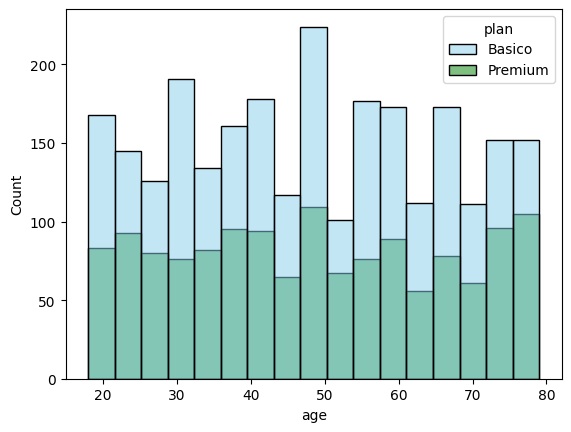

In [163]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    multiple='layer'
)
plt.show()

💡Insights: 
- La distribución de edad es relativamente uniforme y no presenta un sesgo marcado. Ambos planes muestran un comportamiento similar, con usuarios distribuidos aproximadamente entre los 18 y 80 años. No se observa una diferencia clara en la edad según el plan.

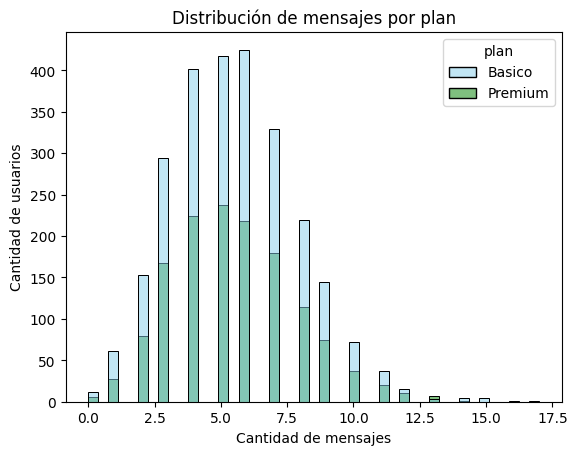

In [164]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    multiple='layer'
)

plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La cantidad de mensajes presenta una distribución sesgada a la derecha en ambos planes. La mayor concentración de usuarios se encuentra aproximadamente entre 3 y 8 mensajes, mientras que pocos usuarios registran cantidades mayores. Ambos planes presentan un patrón similar.

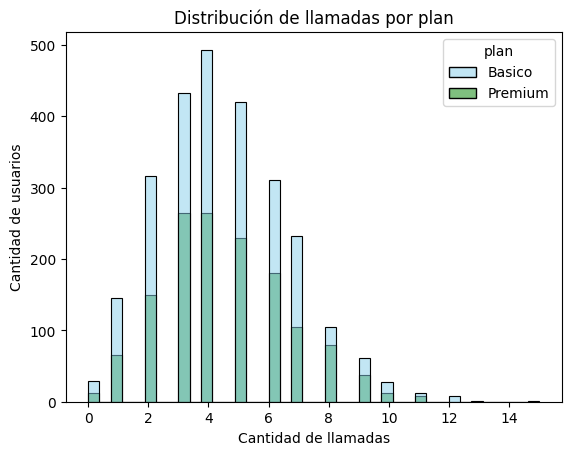

In [165]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    multiple='layer'
)

plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La distribución de llamadas está sesgada a la derecha en ambos planes. La mayor concentración se encuentra entre 2 y 6 llamadas, mientras que son menos frecuentes los usuarios con más de 8 llamadas. No se observa una diferencia marcada en el patrón de uso entre los planes.

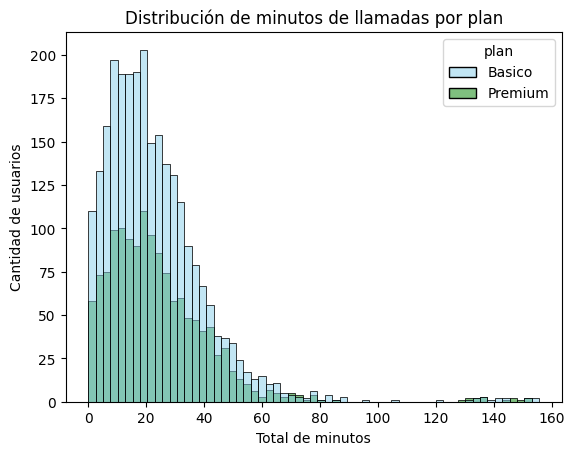

In [166]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    multiple='layer'
)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Total de minutos')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- El total de minutos de llamadas presenta una distribución claramente sesgada a la derecha en ambos planes. La mayoría de los usuarios concentra su consumo en los primeros rangos de minutos, mientras que algunos usuarios presentan valores considerablemente mayores, llegando incluso a superar los 100 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

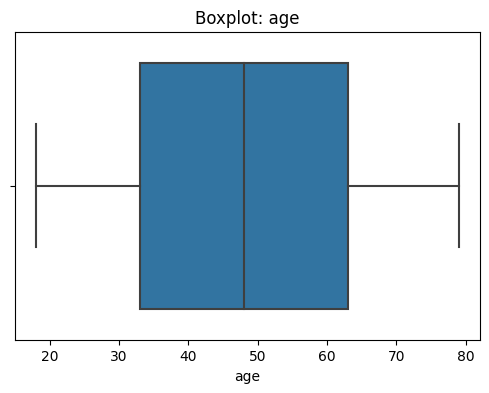

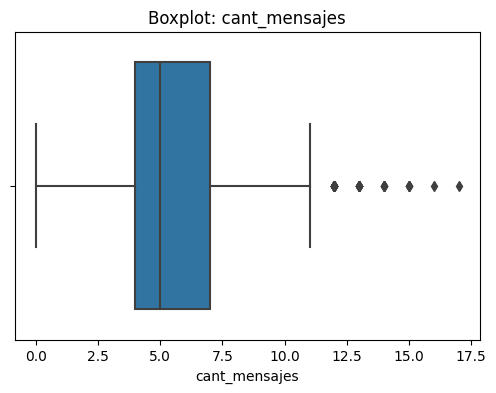

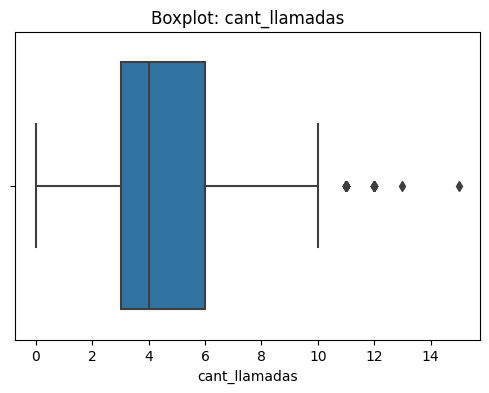

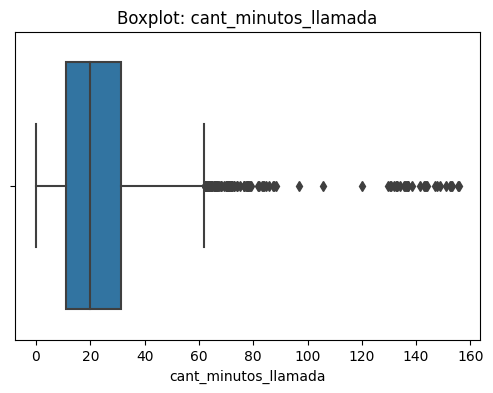

In [167]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: Se identifican varios outliers hacia valores altos, correspondientes a usuarios que envían una cantidad de mensajes considerablemente mayor que la mayoría. La distribución presenta una concentración principal entre aproximadamente 3 y 7 mensajes.
- cant_llamadas: Se identifican algunos outliers hacia valores altos, correspondientes a usuarios que realizan un número de llamadas superior al comportamiento habitual. La mayoría de los usuarios se concentra aproximadamente entre 3 y 7 llamadas.
- cant_minutos_llamada: Se observa una cantidad considerable de outliers hacia valores altos, lo que indica que algunos usuarios acumulan muchos más minutos de llamadas que la mayoría. Es la variable que presenta mayor presencia de valores extremos.

In [168]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'\n{col}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite superior: {limite_superior}')




cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575


In [169]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se identifican outliers por encima de 11.5 mensajes, con un máximo de 17. Se recomienda mantenerlos, ya que pueden representar usuarios con un uso elevado y no necesariamente errores en los datos.
- cant_llamadas: mantener o no outliers, porqué? Se identifican outliers por encima de 10.5 llamadas, con un máximo de 15. Se recomienda mantenerlos, debido a que pueden corresponder a usuarios con un comportamiento de uso intensivo y no representan necesariamente datos incorrectos.
- cant_minutos_llamada: mantener o no outliers, porqué? Se identifican numerosos outliers por encima de 61.86 minutos, alcanzando un máximo de 155.69 minutos. Se recomienda mantenerlos, ya que los valores elevados pueden representar un consumo real del servicio y eliminarlos podría ocasionar pérdida de información relevante sobre los usuarios de mayor uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos.

In [170]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(
    [
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
    ],
    [
        'Bajo uso',
        'Uso medio'
    ],
    default='Alto uso'
)

In [171]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [172]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,
        user_profile['age'] < 60
    ],
    [
        'Joven',
        'Adulto'
    ],
    default='Adulto Mayor'
)

In [173]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

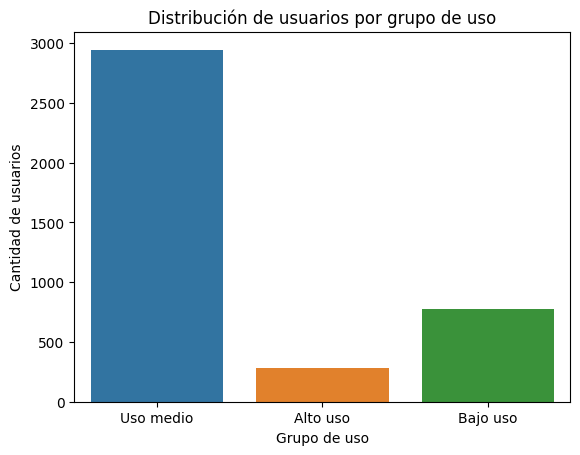

In [174]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

plt.show()

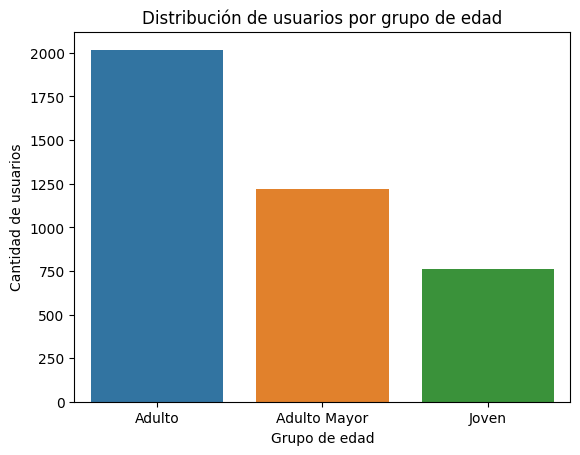

In [175]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **El análisis muestra que ConnectaTel cuenta principalmente con clientes adultos y de uso medio, mientras que el plan Básico concentra una parte importante de la base. La edad no representa un factor decisivo en el comportamiento, por lo que la segmentación por nivel de uso resulta más útil para tomar decisiones comerciales. Los valores extremos encontrados corresponden principalmente a usuarios de alto consumo y representan una oportunidad para desarrollar planes, complementos y estrategias de fidelización específicas. Se recomienda utilizar el plan Básico como vía de captación y entrada, mientras que Premium debe orientarse a usuarios de mayor consumo y potencial de valor. En conjunto, una estrategia basada en el comportamiento real de los clientes permitiría mejorar la retención, incrementar las conversiones hacia Premium y atraer nuevos usuarios mediante ofertas más segmentadas.**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Los datos presentaban varios problemas de calidad y consistencia. Se identificaron valores faltantes en city (469 registros; 1.17%), churn_date (3,435; 8.59%), date (50; 0.125%), duration (22,076; 55.19%) y length (17,896; 44.74%). No todos los valores nulos representan errores. Los faltantes de duration y length dependen del tipo de registro: duration corresponde a llamadas y length a mensajes de texto, por lo que estos nulos son esperados y no deben reemplazarse por cero. En churn_date, los nulos pueden corresponder a clientes que continúan activos. Los pocos nulos de date podrían eliminarse por representar únicamente el 0.125% de los registros, mientras que city requiere revisar el significado de la ausencia antes de imputarla. También se encontraron problemas de formato en las fechas, incluyendo un error de captura en usage["date"], por lo que fue necesario normalizarlas. Finalmente, se detectó un valor mínimo inusual en age que debe validarse. user_id, por el contrario, no presentó anomalías relevantes


🔍 **Segmentos por Edad**
El grupo de Adultos es el segmento etario más numeroso de la base de clientes. Sin embargo, la edad no parece ser un factor determinante del comportamiento de consumo, ya que no se observa una variabilidad suficientemente marcada entre los grupos de edad que permita relacionarla directamente con un mayor o menor uso del servicio..


📊 **Segmentos por Nivel de Uso**
El grupo de Uso medio concentra la mayor cantidad de clientes, lo que indica que la mayoría mantiene un consumo moderado pero frecuente. En términos generales, los usuarios realizan alrededor de 5.5 mensajes, 4.5 llamadas y 23.3 minutos de llamadas. Por ello, el comportamiento predominante de la base corresponde a un nivel de consumo moderado y recurrente.


➡️ Esto sugiere que, en conjunto, el segmento predominante está compuesto por adultos con un nivel de uso medio. Este grupo representa una referencia importante para diseñar estrategias de retención, fidelización y crecimiento, al tratarse del perfil más representativo de la base de clientes.


💡 **Recomendaciones**
- Fortalecer el plan Básico como producto de entrada
- Impulsar la migración de usuarios hacia Premium
- Diseñar estrategias específicas para el segmento Adulto + Uso medio
- Crear ofertas para usuarios de alto consumo
- Implementar estrategias de fidelización
- Mejorar el seguimiento de los datos:

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`